In [2]:
from langgraph.graph import StateGraph,END
import random
from typing import TypedDict,Dict,List

In [3]:
class AgentState(TypedDict):
    name:str
    number:List[int]
    counter:int #stopping condition for the loop note-Mostly we don't know in the start the like what all we need to have for our agent we just add up here whenever we need we will only know when we plan it an extreme level
    

In [4]:
def greeting(state:AgentState)->AgentState:
    """You are an greeting node say hi to the person"""
    state["name"]=f"Hey hello there,{state['name']}"#note if we are using "" outside then we use inside this single one ''
    #we initialize counter variable here now 
    state["counter"]=0 #if this line is not there it will be just keep on incrementing and now with this it will not actually we need only 5 so starting at 0 we will get 5 but if we kept -2 instead of 0 we will get the 7 numbers instead of 5
    
def random_node(state:AgentState)->AgentState:
    """Generates an random numbers 0 to 10"""
    state["number"].append(random.randint(0,10))
    state["counter"] +=1
    
    return state 

#now here clint doesn't need an router so how to do we add an conditional_edge now 

def should_continue(state:AgentState)->AgentState:
    """Function to decide what to do next""" #aka like router now here we do is looping logic nxt line 
    if state["counter"]<5:
        print("Entering loop",state["counter"])
        return "loop"
    else:
        return "exit" # here we are exiting the loop  
    
    
#our flow/Map:greeting->random->random->random->random->random->END
    

In [5]:
graph=StateGraph(AgentState)
graph.add_node("greeting",greeting)
graph.add_node("random",random_node)
#adding edge aka arrow between them 
graph.add_edge("greeting","random")

#now add conditional edges
graph.add_conditional_edges(
     "random", #source
     should_continue, #same like decide node but we route should_continue like Action-This is the function that determine what edge to use that is implemented by should_continue
    {
        "loop":"random", #self-loop back to the same node,same as we given in the should_continue thing same typo, the loop is the one which is outputed then we need to go back into it random node which we put on the top or else it will go to the end part
        "exit":END #end the graph
    }
)
graph.set_entry_point("greeting") # no need to put end as we have kept in the above line END

app=graph.compile()

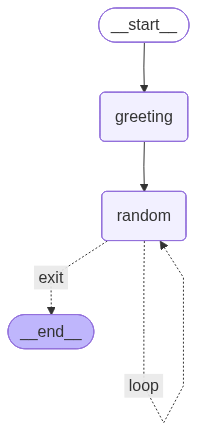

In [6]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
app.invoke({"name":"tony","number":[],"counter":-1})# we get some random numbers in the list we created why -1 simple as in above you wrote 1 so -1+1=0 so we will be starting at 0 

Entering loop 0
Entering loop 1
Entering loop 2
Entering loop 3
Entering loop 4


{'name': 'tony', 'number': [9, 4, 1, 7, 8, 3], 'counter': 5}

In [8]:
from typing import TypedDict,Dict,List
from langgraph.graph import StateGraph
import random

In [9]:
class AgentState(TypedDict):
    name:str
    number:List[int]
    counter:int

In [10]:
def greeting(state:AgentState)->AgentState:
    """You are the second greeting node say hi"""
    state["name"]=f"hello my name is {state['name']}"
    return state

def rn2(state:AgentState)->AgentState:
    """Generating random number 0-10"""
    state["number"].append(random.randint(0,10))
    state["counter"]+=1
    return state

def sc(state:AgentState)->AgentState:
 
    if state["counter"]<5:
        print("Entering loop",state["counter"])
        return "loop"
    else:
        return "exit"

In [11]:
g1=StateGraph(AgentState)
g1.add_node("greet2",greeting)
g1.add_node("random2",rn2)
g1.add_edge("greet2","random2") # remember after adding 2 node always put the edge and connect them 
g1.add_conditional_edges(
    "random2",
    sc,
    {
        "loop":"random2",#same name what we have give in the top
        "exit":END
    }
)
g1.set_entry_point("greet2")
ape=g1.compile()


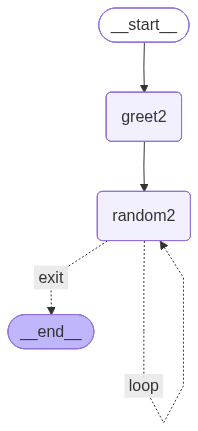

In [12]:
from IPython.display import Image,display
display(Image(ape.get_graph().draw_mermaid_png()))

In [13]:
ape.invoke({"name":"John","number":[],"counter":-1})

Entering loop 0
Entering loop 1
Entering loop 2
Entering loop 3
Entering loop 4


{'name': 'hello my name is John', 'number': [8, 1, 7, 5, 4, 5], 'counter': 5}

In [14]:
class AgentState(TypedDict):
    name:str
    numb:List[int]
    latest:int
    counter:int
    

In [15]:
def greeting_node1(state:AgentState)->AgentState:
    """You are an greeting agent just say hi to the people"""
    state["name"]=f"Hello sir your name is{state['name']}"
    return state

def random2(state:AgentState)->AgentState:
    """Generate numbers from 0-10"""
    state["numb"].append(random.randint(0,10))
    state['counter']+=1
    return state 
   
def should_continue(state:AgentState)->AgentState:
    if state['latest']%2==0:
        return "exit"
    else:
        return "loop"
    

In [16]:
g2=StateGraph(AgentState)
g2.add_node("greet3",greeting_node1)
g2.add_node("random",random2)
g2.add_edge("greet3","random")
g2.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop":"random",
        "exit":END
    }
)
g2.set_entry_point("greet3")
apr=g2.compile()

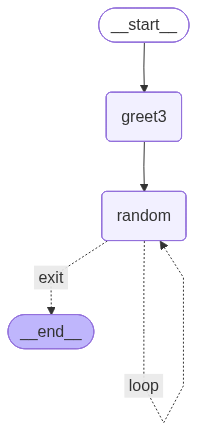

In [17]:
from IPython.display import Image,display
display(Image(apr.get_graph().draw_mermaid_png()))

In [18]:
ape.invoke({"name":"Johnathon","number":[],"counter":-1})

Entering loop 0
Entering loop 1
Entering loop 2
Entering loop 3
Entering loop 4


{'name': 'hello my name is Johnathon',
 'number': [5, 5, 7, 8, 0, 10],
 'counter': 5}

In [19]:
class AgentState(TypedDict):
    number:List[int]
    latest:int
    counter:int

In [ ]:
def checknumber(state:AgentState)->AgentState:
    """Generate an number from 0-10"""
    state["number"].append(random.randint(0,30))
    state["latest"]=state["number"][-1]
    state["counter"]+=1
    return state

def should_continue(state:AgentState)->AgentState:
    if state['latest']%5==0:
        return "exit"
    if state["counter"]==8:
        return "exit"
    else:
        return "loop"

In [35]:
g3=StateGraph(AgentState)
g3.add_node("checks",checknumber)
g3.add_conditional_edges(
    "checks",
    should_continue,{
        "loop":"checks",
        "exit":END
    }
)
g3.set_entry_point("checks")
app1=g3.compile()

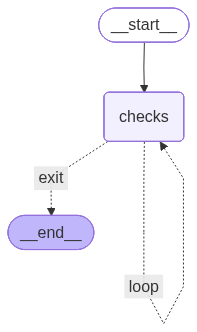

In [36]:
from IPython.display import Image,display
display(Image(app1.get_graph().draw_mermaid_png()))

In [39]:
app1.invoke({"number":[],"latest":0,"counter":0})

{'number': [18, 13, 13, 6, 30], 'latest': 30, 'counter': 5}

In [42]:
class AgentState(TypedDict):
    secret:int
    guess:list[int]
    latest:int
    counter:int

In [47]:
def generate_guess(state:AgentState)->AgentState:
    """This is to generate the numbers randomly"""
    state['guess'].append(random.randint(0,30))
    state['latest']=state['guess'][-1] #why -1 cause we have to access the last number in the guess thing
    state['counter']+=1
    return state 

def should_checks(state: AgentState)->AgentState:
   if state['latest']== state["secret"]:
       return "exit"
   elif state["counter"]==7:
       return "exit"
   else:
       return "loop"

In [48]:
g5=StateGraph(AgentState)
g5.add_node("Generator",generate_guess)
g5.add_conditional_edges(
    "Generator",
    should_checks,{
        "loop":"Generator",
        "exit":END
    }
)
g5.set_entry_point("Generator")
app2=g5.compile()

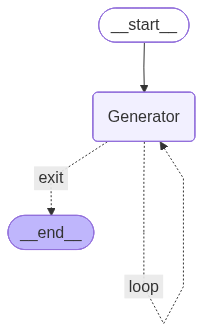

In [ ]:
from IPython.display import Image,display
display(Image(app2.get_graph().draw_mermaid_png()))

In [50]:
app2.invoke({"secret":17,"guess":[],"latest":0,"counter":0})

{'secret': 17, 'guess': [12, 18, 16, 14, 27, 21, 3], 'latest': 3, 'counter': 7}

In [51]:
class AgentState(TypedDict):
    alien_x:int
    aliens:list[int]
    counter:int
    latest:int

In [ ]:
def ominitrix(state:AgentState)->AgentState:
    """This is just an dial thing that will do +1 as we go"""
    state["aliens"].append(random.randint(0,11))
    state['latest']=state['aliens'][-1]
    state['counter']+=1
    return state

def next_move(state:AgentState)->AgentState:
    if state["latest"]==state["alien_x"]:
        return "exit"
    else:
        return "loop"

In [71]:
g6=StateGraph(AgentState)
g6.add_node("ominitrix-1",ominitrix)
g6.add_conditional_edges(
    "ominitrix-1",
    next_move,
    {
        "loop":"ominitrix-1",
        "exit":END
    }    
)
g6.set_entry_point("ominitrix-1")
app3=g6.compile()

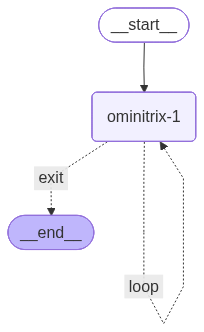

In [64]:
from IPython.display import Image,display
display(Image(app3.get_graph().draw_mermaid_png()))


In [72]:
app3.invoke({"alien_x":11,"aliens":[],"counter":0,"latest":0})


{'alien_x': 11, 'aliens': [7, 5, 0, 5, 7, 7, 11], 'counter': 7, 'latest': 11}